In [11]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['font.family'] = 'Arial'

In [ ]:
from dataclasses import dataclass
from typing import List
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import time

@dataclass
class NormativeArgs:
    # --- 1. Data Dimensions ---
    n_genes: int            
    n_batch_subcategories: List[int]
    n_phenotypes: int       
    n_qc_metrics: int       
    
    # --- 2. Model Architecture ---
    z_dim: int = 2          
    hidden_dim: int = 128   
    
    # --- 3. Training Hyperparameters ---
    epochs: int = 100
    batch_size: int = 128
    learning_rate: float = 1e-3
    seed: int = 42
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
    weight_decay: float = 1e-4  
    grad_clip: float = 5.0      
    l2_lambda_pheno: float = 0.1  
    warmup_epochs: int = 10       
    kl_max_beta: float = 2.0      
    kl_anneal_epochs: int = 20    
    hc_index: int = 0
    save_path: str = None


class NormativeModel(nn.Module):
    def __init__(self, args):
        super().__init__()
        self.args = args
        # 각 배치 컬럼의 총 차원 계산
        total_batch_dims = sum(args.n_batch_subcategories)
        # --- Encoder ---
        self.encoder_input_dim = args.n_genes + total_batch_dims + args.n_qc_metrics
        self.encoder_fc1 = nn.Linear(self.encoder_input_dim, args.hidden_dim)
        self.encoder_fc2 = nn.Linear(args.hidden_dim, args.hidden_dim)
        
        self.z_mean = nn.Linear(args.hidden_dim, args.z_dim)
        self.z_log_var = nn.Linear(args.hidden_dim, args.z_dim)

        # --- Decoder ---
        self.global_intercept = nn.Parameter(torch.zeros(args.n_genes))
        
        self.batch_intercepts = nn.ModuleList([
            nn.Embedding(num_cats, args.n_genes) 
            for num_cats in args.n_batch_subcategories
        ])
        for layer in self.batch_intercepts:
            nn.init.zeros_(layer.weight)

        self.qc_decoder = nn.Sequential(
            nn.Linear(args.n_qc_metrics, 32),
            nn.ReLU(),
            nn.Linear(32, args.n_genes) 
        )
        nn.init.normal_(self.qc_decoder[-1].weight, std=0.01)
        nn.init.zeros_(self.qc_decoder[-1].bias)
        
        self.pheno_offset = nn.Embedding(args.n_phenotypes, args.n_genes)
        nn.init.zeros_(self.pheno_offset.weight)
        
        self.z_decoder = nn.Linear(args.z_dim, args.n_genes, bias=False)
        self.px_r = nn.Parameter(torch.full((args.n_genes,), 2.302))
            
    def init_global_intercept(self, count_data):
        with torch.no_grad():
            if not isinstance(count_data, torch.Tensor):
                count_data = torch.tensor(count_data, dtype=torch.float32)

            lib_sizes = count_data.sum(dim=1, keepdim=True)
            freqs = count_data / (lib_sizes + 1e-8)
            log_freqs = torch.log(freqs.mean(dim=0) + 1e-8)
            self.global_intercept.data.copy_(log_freqs.to(self.global_intercept.device))
        print(f"✅ Global Intercept Initialized (Scale Fixed).")

    def reparameterize(self, mu, log_var):
        if self.training:
            std = torch.exp(0.5 * log_var)
            eps = torch.randn_like(std)
            return mu + eps * std
        else : 
            return mu
        
        
    def forward(self, x, batch_idx, qc, pheno_idx, lib_log):
        if lib_log.dim() == 1: lib_log = lib_log.view(-1, 1)

        # --- 1. Encoder Input ---
        batch_one_hots = [F.one_hot(batch_idx[:, i], num_classes=n).float() for i, n in enumerate(self.args.n_batch_subcategories)]
        batch_cat = torch.cat(batch_one_hots, dim=1) 
        enc_in = torch.cat([torch.log1p(x), batch_cat, qc], dim=1)
        
        h = F.relu(self.encoder_fc2(F.relu(self.encoder_fc1(enc_in))))
        z_mu, z_log_var = self.z_mean(h), self.z_log_var(h)
        z = self.reparameterize(z_mu, z_log_var)
        
        # --- 2. Decoder Output ---
        batch_effect_sum = sum(layer(batch_idx[:, i]) for i, layer in enumerate(self.batch_intercepts))
            
        log_mu = (self.global_intercept + 
                  batch_effect_sum + 
                  self.qc_decoder(qc) + 
                  self.pheno_offset(pheno_idx) + 
                  self.z_decoder(z) + 
                  lib_log)
        
        theta = torch.exp(self.px_r).unsqueeze(0).expand(x.size(0), -1)
        
        return torch.exp(log_mu), theta, z_mu, z_log_var



class NormativeTrainer:
    def __init__(self, model, args, train_loader, val_loader=None):
        self.model = model.to(args.device)
        self.args = args
        self.train_loader = train_loader
        self.val_loader = val_loader
        
        self.optimizer = optim.AdamW(
            model.parameters(), 
            lr=args.learning_rate, 
            weight_decay=args.weight_decay
        )        
        
        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_recon': [], 'val_recon': [],
            'train_kl': [], 'val_kl': []
        }
        
        self.current_epoch = 0
        self.current_kl_beta = 0.0
        self.is_warmup = True
        self.best_val_loss = float('inf')

    def train(self):
        print(f"🚀 Start Training on {self.args.device} | Epochs: {self.args.epochs}")
        start_time = time.time()

        for epoch in range(self.args.epochs):
            self.current_epoch = epoch
            self._update_schedulers() 

            # --- Training Loop ---
            train_metrics = self._train_epoch()
            self.history['train_loss'].append(train_metrics['loss'])
            self.history['train_recon'].append(train_metrics['recon'])
            self.history['train_kl'].append(train_metrics['kl'])

            # --- Validation Loop ---
            val_log = ""
            if self.val_loader:
                val_metrics = self._validate_epoch()
                v_loss = val_metrics['loss']
                
                self.history['val_loss'].append(v_loss)
                self.history['val_recon'].append(val_metrics['recon'])
                self.history['val_kl'].append(val_metrics['kl'])
                if v_loss < self.best_val_loss:
                    self.best_val_loss = v_loss
                    if self.args.save_path:
                        self.save_checkpoint(self.args.save_path)
                    save_msg = "(*)" 
                else:
                    save_msg = ""
                
                val_log = (f"| Val Loss: {v_loss:.2f} "
                           f"(Recon: {val_metrics['recon']:.2f}, KL: {val_metrics['kl']:.2f}) {save_msg}")

            # --- Logging ---
            if epoch % 5 == 0 or epoch == self.args.epochs - 1:
                elapsed = time.time() - start_time
                print(f"[Ep {epoch:03d}] Train Loss: {train_metrics['loss']:.2f} {val_log} | "
                      f"Beta: {self.current_kl_beta:.2f} | Warmup: {self.is_warmup}")
                                
    def save_checkpoint(self, path):
        checkpoint = {
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'best_val_loss': self.best_val_loss,
            'history': self.history,
            'epoch': self.current_epoch,
            'args_dict': vars(self.args) 
        }
        torch.save(checkpoint, path)
        print(f"Checkpoint saved at Epoch {self.current_epoch} to {path}")

    @classmethod
    def load_from_checkpoint(cls, path, train_loader, val_loader=None, device='cuda'):
        print(f"Loading checkpoint from '{path}'...")
        
        # 순수 딕셔너리와 텐서만 저장되어 있으므로 weights_only=True로 안전하게 로드 가능
        checkpoint = torch.load(path, map_location=device, weights_only=True)
        
        # 딕셔너리로부터 Args 객체 재조립
        from __main__ import NormativeArgs
        args = NormativeArgs(**checkpoint['args_dict'])
        args.device = device 
        
        # Model & Trainer 복원
        model = NormativeModel(args)
        model.load_state_dict(checkpoint['model_state_dict'])
        
        trainer = cls(model, args, train_loader, val_loader)
        trainer.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        trainer.history = checkpoint.get('history', trainer.history)
        trainer.best_val_loss = checkpoint.get('best_val_loss', float('inf'))
        trainer.current_epoch = checkpoint.get('epoch', 0)
        
        trainer._update_schedulers()
        print(f"✅ Checkpoint loaded successfully! (Saved at Epoch {trainer.current_epoch})")
        return trainer
    
    def _train_epoch(self):
        self.model.train()
        total_loss, total_recon, total_kl = 0, 0, 0
        
        for batch in self.train_loader:
            x, batch_idx, qc, pheno_idx, lib_log = [b.to(self.args.device) for b in batch]
            
            mu, theta, z_mu, z_log_var = self.model(x, batch_idx, qc, pheno_idx, lib_log)
            
            # Loss 계산 시 상세 지표도 함께 추출
            recon_loss = self._negative_binomial_loss(x, mu, theta)
            kl_loss = -0.5 * torch.sum(1 + z_log_var - z_mu.pow(2) - z_log_var.exp(), dim=1).mean()
            
            # Total Loss (L2 포함)
            loss = self._compute_loss(x, mu, theta, z_mu, z_log_var)
            
            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.args.grad_clip)
            self._apply_hc_constraint()
            self.optimizer.step()
            self._enforce_hc_zero()
            
            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()
            
        n = len(self.train_loader)
        return {'loss': total_loss / n, 'recon': total_recon / n, 'kl': total_kl / n}
    

    def _update_schedulers(self):
        if self.current_epoch < self.args.warmup_epochs:
            if not self.is_warmup:
                print(f"   -> Warmup Start: Freezing Phenotype Offset")
            self.is_warmup = True
            self.model.pheno_offset.requires_grad_(False)
        else:
            if self.is_warmup:
                print(f"   -> Warmup End: Unfreezing Phenotype Offset")
            self.is_warmup = False
            self.model.pheno_offset.requires_grad_(True)

        if self.current_epoch < self.args.kl_anneal_epochs:
            progress = self.current_epoch / self.args.kl_anneal_epochs
            self.current_kl_beta = self.args.kl_max_beta * progress
        else:
            self.current_kl_beta = self.args.kl_max_beta

    def _validate_epoch(self):
        self.model.eval() 
        total_loss = 0
        total_recon = 0
        total_kl = 0
        
        with torch.no_grad():
            for batch in self.val_loader:
                x, batch_idx, qc, pheno_idx, lib_log = [b.to(self.args.device) for b in batch]
                # Forward
                mu, theta, z_mu, z_log_var = self.model(x, batch_idx, qc, pheno_idx, lib_log)
                # --- Component별 Loss 계산 (모니터링용) ---
                recon_loss = self._negative_binomial_loss(x, mu, theta)
                kl_loss = -0.5 * torch.sum(1 + z_log_var - z_mu.pow(2) - z_log_var.exp(), dim=1).mean()
                l2_loss = 0.0
                if not self.is_warmup:
                    l2_loss = torch.sum(self.model.pheno_offset.weight ** 2)
                
                current_l2_lambda = 0.0 if self.is_warmup else self.args.l2_lambda_pheno
                loss = recon_loss + (self.current_kl_beta * kl_loss) + (current_l2_lambda * l2_loss)
                total_loss += loss.item()
                total_recon += recon_loss.item()
                total_kl += kl_loss.item()
        
        n_batches = len(self.val_loader)
        return {
            'loss': total_loss / n_batches,
            'recon': total_recon / n_batches,
            'kl': total_kl / n_batches
        }

    def _compute_loss(self, x, mu, theta, z_mu, z_log_var):
        recon_loss = self._negative_binomial_loss(x, mu, theta)
        kl_loss = -0.5 * torch.sum(1 + z_log_var - z_mu.pow(2) - z_log_var.exp(), dim=1).mean()
        l2_loss = 0.0
        if not self.is_warmup:
            l2_loss = torch.sum(self.model.pheno_offset.weight ** 2)
        
        current_l2_lambda = 0.0 if self.is_warmup else self.args.l2_lambda_pheno
        total = recon_loss + (self.current_kl_beta * kl_loss) + (current_l2_lambda * l2_loss)
        return total

    def _negative_binomial_loss(self, x, mu, theta, eps=1e-8):
        log_theta_mu = torch.log(theta + mu + eps)
        log_theta = torch.log(theta + eps)
        log_mu = torch.log(mu + eps)
        
        lgamma_x_theta = torch.lgamma(x + theta)
        lgamma_theta = torch.lgamma(theta)
        lgamma_x_plus_1 = torch.lgamma(x + 1)
        
        nll = -(lgamma_x_theta - lgamma_theta - lgamma_x_plus_1 + 
                theta * (log_theta - log_theta_mu) + 
                x * (log_mu - log_theta_mu))
        return torch.mean(torch.sum(nll, dim=1))

    def _apply_hc_constraint(self):
        if self.model.pheno_offset.weight.requires_grad:
            if self.model.pheno_offset.weight.grad is not None:
                self.model.pheno_offset.weight.grad[self.args.hc_index] = 0.0

    def _enforce_hc_zero(self):
        with torch.no_grad():
            self.model.pheno_offset.weight[self.args.hc_index].fill_(0.0)

In [52]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder

class NormativeDataset(Dataset):
    def __init__(self, x, batch_idx, qc, pheno_idx, lib_log):
        self.x = torch.FloatTensor(x)
        self.batch_idx = torch.LongTensor(batch_idx) # Shape: (N, 4)
        self.qc = torch.FloatTensor(qc)
        self.pheno_idx = torch.LongTensor(pheno_idx)
        self.lib_log = torch.FloatTensor(lib_log)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.batch_idx[idx], self.qc[idx], self.pheno_idx[idx], self.lib_log[idx]

def prepare_normative_loaders(expr_np, batch_df, qc_df, label_df, batch_size=128, resampling=True):
    batch_encoders = []
    batch_indices_list = []
    n_batch_subcategories = [] 
    
    for col in batch_df.columns:
        le = LabelEncoder()
        encoded = le.fit_transform(batch_df[col].astype(str))
        
        batch_indices_list.append(encoded)
        n_batch_subcategories.append(len(le.classes_))
        batch_encoders.append(le)
        
    batch_indices_combined = np.stack(batch_indices_list, axis=1)
    granular_id = batch_df.apply(lambda x: "_".join(x.astype(str)), axis=1)
    stratify_key = label_df.astype(str) + "||" + granular_id.astype(str)
    le_pheno = LabelEncoder()
    y_encoded = le_pheno.fit_transform(label_df)
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    
    try:
        train_idx, val_idx = next(sss.split(expr_np, stratify_key))
    except ValueError:
        print("Fallback split: Stratification by Label only.")
        train_idx, val_idx = next(sss.split(expr_np, y_encoded))

    x_train, x_val = expr_np[train_idx], expr_np[val_idx]
    b_train, b_val = batch_indices_combined[train_idx], batch_indices_combined[val_idx] # (N, 4)
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]
    
    scaler = StandardScaler()
    qc_train = scaler.fit_transform(qc_df.iloc[train_idx])
    qc_val = scaler.transform(qc_df.iloc[val_idx])
    
    lib_train = np.log(x_train.sum(axis=1) + 1)
    lib_val = np.log(x_val.sum(axis=1) + 1)

    train_ds = NormativeDataset(x_train, b_train, qc_train, y_train, lib_train)
    val_ds = NormativeDataset(x_val, b_val, qc_val, y_val, lib_val)

    sampler = None
    if resampling:
        class_counts = np.bincount(y_train)
        weights = 1. / class_counts
        samples_weight = torch.tensor([weights[y] for y in y_train], dtype=torch.double)
        sampler = WeightedRandomSampler(samples_weight, len(samples_weight), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, shuffle=(sampler is None), num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    meta_info = {
        'n_genes': expr_np.shape[1],
        'n_batch_subcategories': n_batch_subcategories, # 리스트 반환
        'n_phenotypes': len(le_pheno.classes_),
        'n_qc_metrics': qc_df.shape[1]
    }
    
    return train_loader, val_loader, meta_info

In [53]:
import scanpy as sc

adata = sc.read_h5ad("OpenAccess_Filtered_Heuristic.h5ad")
x_data = adata.layers['counts']
print(x_data.shape) 
bias_metrics = ['gc_bias_score', 'len_bias_score', 'platelet_score', 'NG80', 'NP80', 'NP80_NG80_ratio','FSR'] # 'log1p_total_counts', 제외
batch_cols = ['BioProject','tissue','Instrument','LibrarySelection']
qc_df = adata.obs[bias_metrics].copy()
print(qc_df.shape) 
batch_df = adata.obs[batch_cols].copy()
print(batch_df.shape) 
label_df = adata.obs['Phenotype'].copy()
print(label_df.shape) 
del adata

train_loader, val_loader, meta_info = prepare_normative_loaders(x_data, 
                                        batch_df,
                                        qc_df,
                                        label_df,
                                        batch_size=128,
                                        resampling=True)

print(meta_info)

(2073, 3394)
(2073, 7)
(2073, 4)
(2073,)
{'n_genes': 3394, 'n_batch_subcategories': [6, 2, 3, 3], 'n_phenotypes': 23, 'n_qc_metrics': 7}


In [54]:
args = NormativeArgs(
    n_genes=meta_info['n_genes'],                  # 3394
    n_batch_subcategories=meta_info['n_batch_subcategories'], # [6, 2, 3, 3]
    n_phenotypes=meta_info['n_phenotypes'],        # 24
    n_qc_metrics=meta_info['n_qc_metrics'],        # 8
    # --- 학습 파라미터 ---
    z_dim=4,              
    hidden_dim=32,
    epochs=250,
    batch_size=256,
    learning_rate=1e-3,
    weight_decay=1e-4,    
    grad_clip=5.0,        
    l2_lambda_pheno=0.01,   
    warmup_epochs=100,
    kl_max_beta=2.0,
    hc_index=9            
)

model = NormativeModel(args)
first_batch = next(iter(train_loader))
first_x = first_batch[0] # (Batch, Genes)
model.init_global_intercept(first_x)

# 4. Trainer 설정 및 시작
trainer = NormativeTrainer(model, args, train_loader, val_loader)
trainer.train()

✅ Global Intercept Initialized (Scale Fixed).
🚀 Start Training on cuda | Epochs: 250
[Ep 000] Train Loss: 28081.00 | Val Loss: 22508.05 (Recon: 22508.05, KL: 2.85) (*) | Beta: 0.00 | Warmup: True
[Ep 005] Train Loss: 18750.45 | Val Loss: 18236.02 (Recon: 18228.61, KL: 14.83) (*) | Beta: 0.50 | Warmup: True
[Ep 010] Train Loss: 17187.43 | Val Loss: 17281.83 (Recon: 17266.01, KL: 15.82) (*) | Beta: 1.00 | Warmup: True
[Ep 015] Train Loss: 16371.73 | Val Loss: 16642.71 (Recon: 16620.16, KL: 15.03) (*) | Beta: 1.50 | Warmup: True
[Ep 020] Train Loss: 15806.95 | Val Loss: 16164.79 (Recon: 16138.32, KL: 13.23) (*) | Beta: 2.00 | Warmup: True
[Ep 025] Train Loss: 15205.93 | Val Loss: 15653.26 (Recon: 15629.24, KL: 12.01) (*) | Beta: 2.00 | Warmup: True
[Ep 030] Train Loss: 14838.41 | Val Loss: 15367.02 (Recon: 15343.71, KL: 11.65) (*) | Beta: 2.00 | Warmup: True
[Ep 035] Train Loss: 14346.93 | Val Loss: 15157.80 (Recon: 15134.84, KL: 11.48) (*) | Beta: 2.00 | Warmup: True
[Ep 040] Train Loss:

### Validation Dataset : 정량적 모델 검정

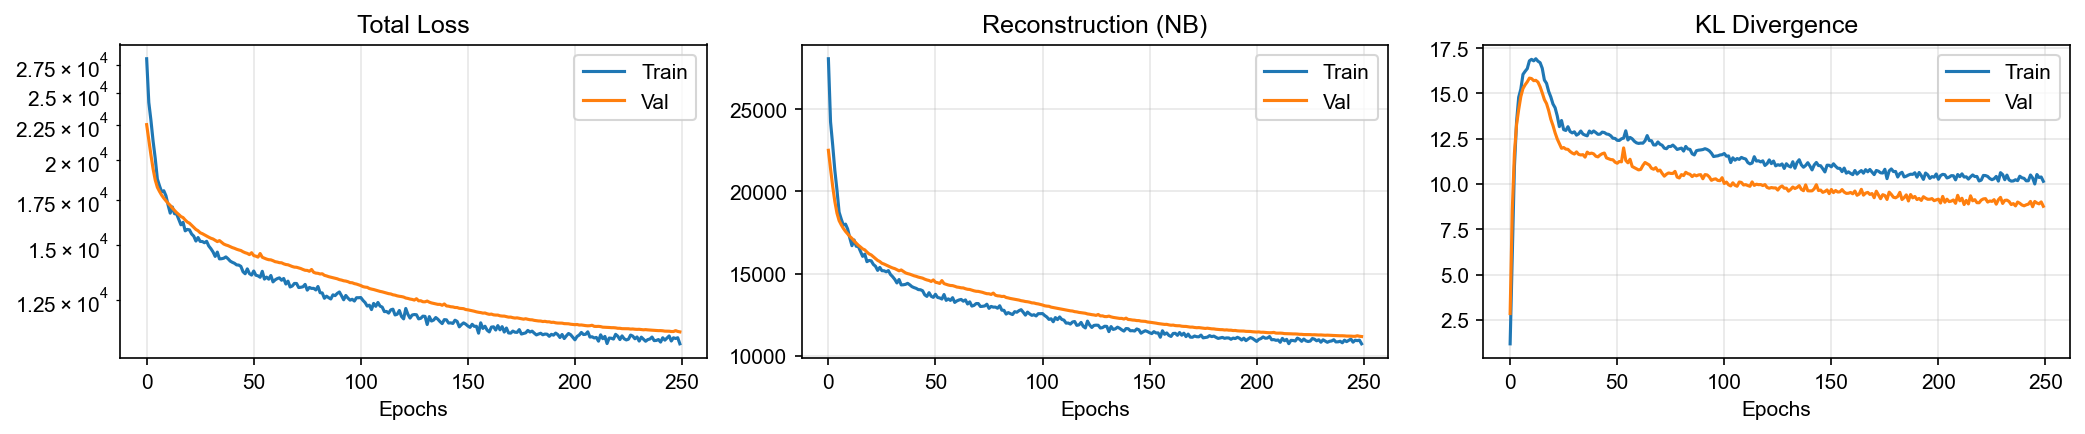

In [56]:
def plot_history(history, figsize=(14, 3)):
    epochs = range(len(history['train_loss']))
    plt.figure(figsize=figsize)

    # 1. Total Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Train')
    if history['val_loss']:
        plt.plot(epochs, history['val_loss'], label='Val')
    plt.title('Total Loss')
    plt.xlabel('Epochs')
    plt.yscale('log')
    plt.legend()
    plt.grid(alpha=0.3)

    # 2. Recon Loss
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_recon'], label='Train')
    if history['val_recon']:
        plt.plot(epochs, history['val_recon'], label='Val')
    plt.title('Reconstruction (NB)')
    plt.xlabel('Epochs')
    plt.legend()
    plt.grid(alpha=0.3)

    # 3. KL Divergence
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['train_kl'], label='Train')
    if history['val_kl']:
        plt.plot(epochs, history['val_kl'], label='Val')
    plt.title('KL Divergence')
    plt.xlabel('Epochs')
    plt.legend()

    plt.tight_layout()
    plt.grid(alpha=0.3)
    plt.show()

plot_history(trainer.history)

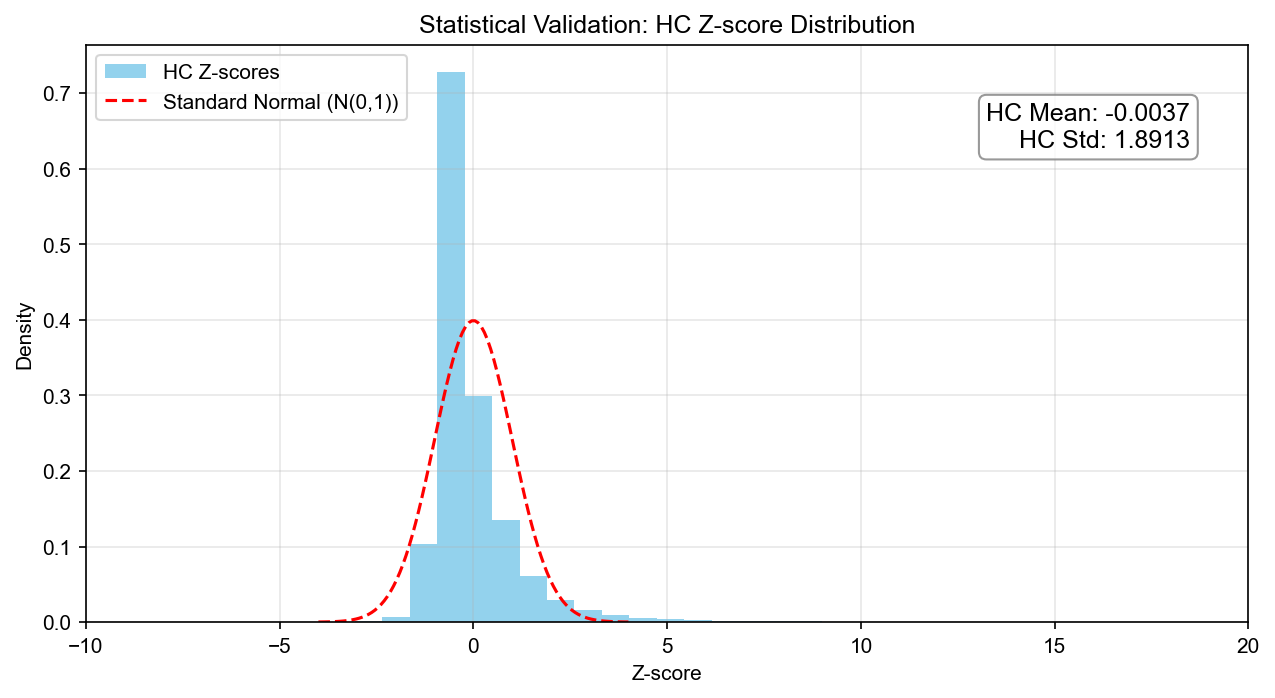

HC Mean: -0.0037 (Ideal: 0)
HC Std: 1.8913 (Ideal: 1)


In [63]:
def calculate_normative_zscore(model, dataloader, device):
    model.eval()
    all_z_scores = []
    all_phenos = []
    
    with torch.no_grad():
        for batch in dataloader:
            x, batch_idx, qc, pheno_idx, lib_log = [b.to(device) for b in batch]
            hc_fix_idx = torch.full_like(pheno_idx, model.args.hc_index)
            mu, theta, _, _ = model(x, batch_idx, qc, hc_fix_idx, lib_log)
            std = torch.sqrt(mu + (mu**2 / theta))
            z = (x - mu) / (std + 1e-8)
            all_z_scores.append(z.cpu())
            all_phenos.append(pheno_idx.cpu())
            
    return torch.cat(all_z_scores), torch.cat(all_phenos)

# 실행
z_scores, phenos = calculate_normative_zscore(model, train_loader, args.device)
def verify_zscore_distribution(z_scores, phenos, hc_index):
    hc_mask = (phenos == hc_index)
    hc_z = z_scores[hc_mask].numpy().flatten()
    
    # 지표 계산
    mean_val = hc_z.mean()
    std_val = hc_z.std()
    
    plt.figure(figsize=(10, 5)) 
    plt.hist(hc_z, bins=500, density=True, alpha=0.9, color='skyblue', label='HC Z-scores')
    
    import numpy as np
    from scipy.stats import norm
    x = np.linspace(-4, 4, 100)
    plt.plot(x, norm.pdf(x, 0, 1), 'r--', label='Standard Normal (N(0,1))')
    
    stats_text = f"HC Mean: {mean_val:.4f}\nHC Std: {std_val:.4f}"
    plt.text(0.95, 0.9, stats_text, 
             transform=plt.gca().transAxes, 
             fontsize=12, 
             verticalalignment='top', 
             horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
    
    plt.title("Statistical Validation: HC Z-score Distribution")
    plt.xlabel("Z-score")
    plt.ylabel("Density")
    plt.legend(loc='upper left') 
    plt.xlim(-10, 20)
    plt.grid(alpha=0.3)

    plt.show()
    
    print(f"HC Mean: {mean_val:.4f} (Ideal: 0)")
    print(f"HC Std: {std_val:.4f} (Ideal: 1)")

verify_zscore_distribution(z_scores, phenos, args.hc_index)

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


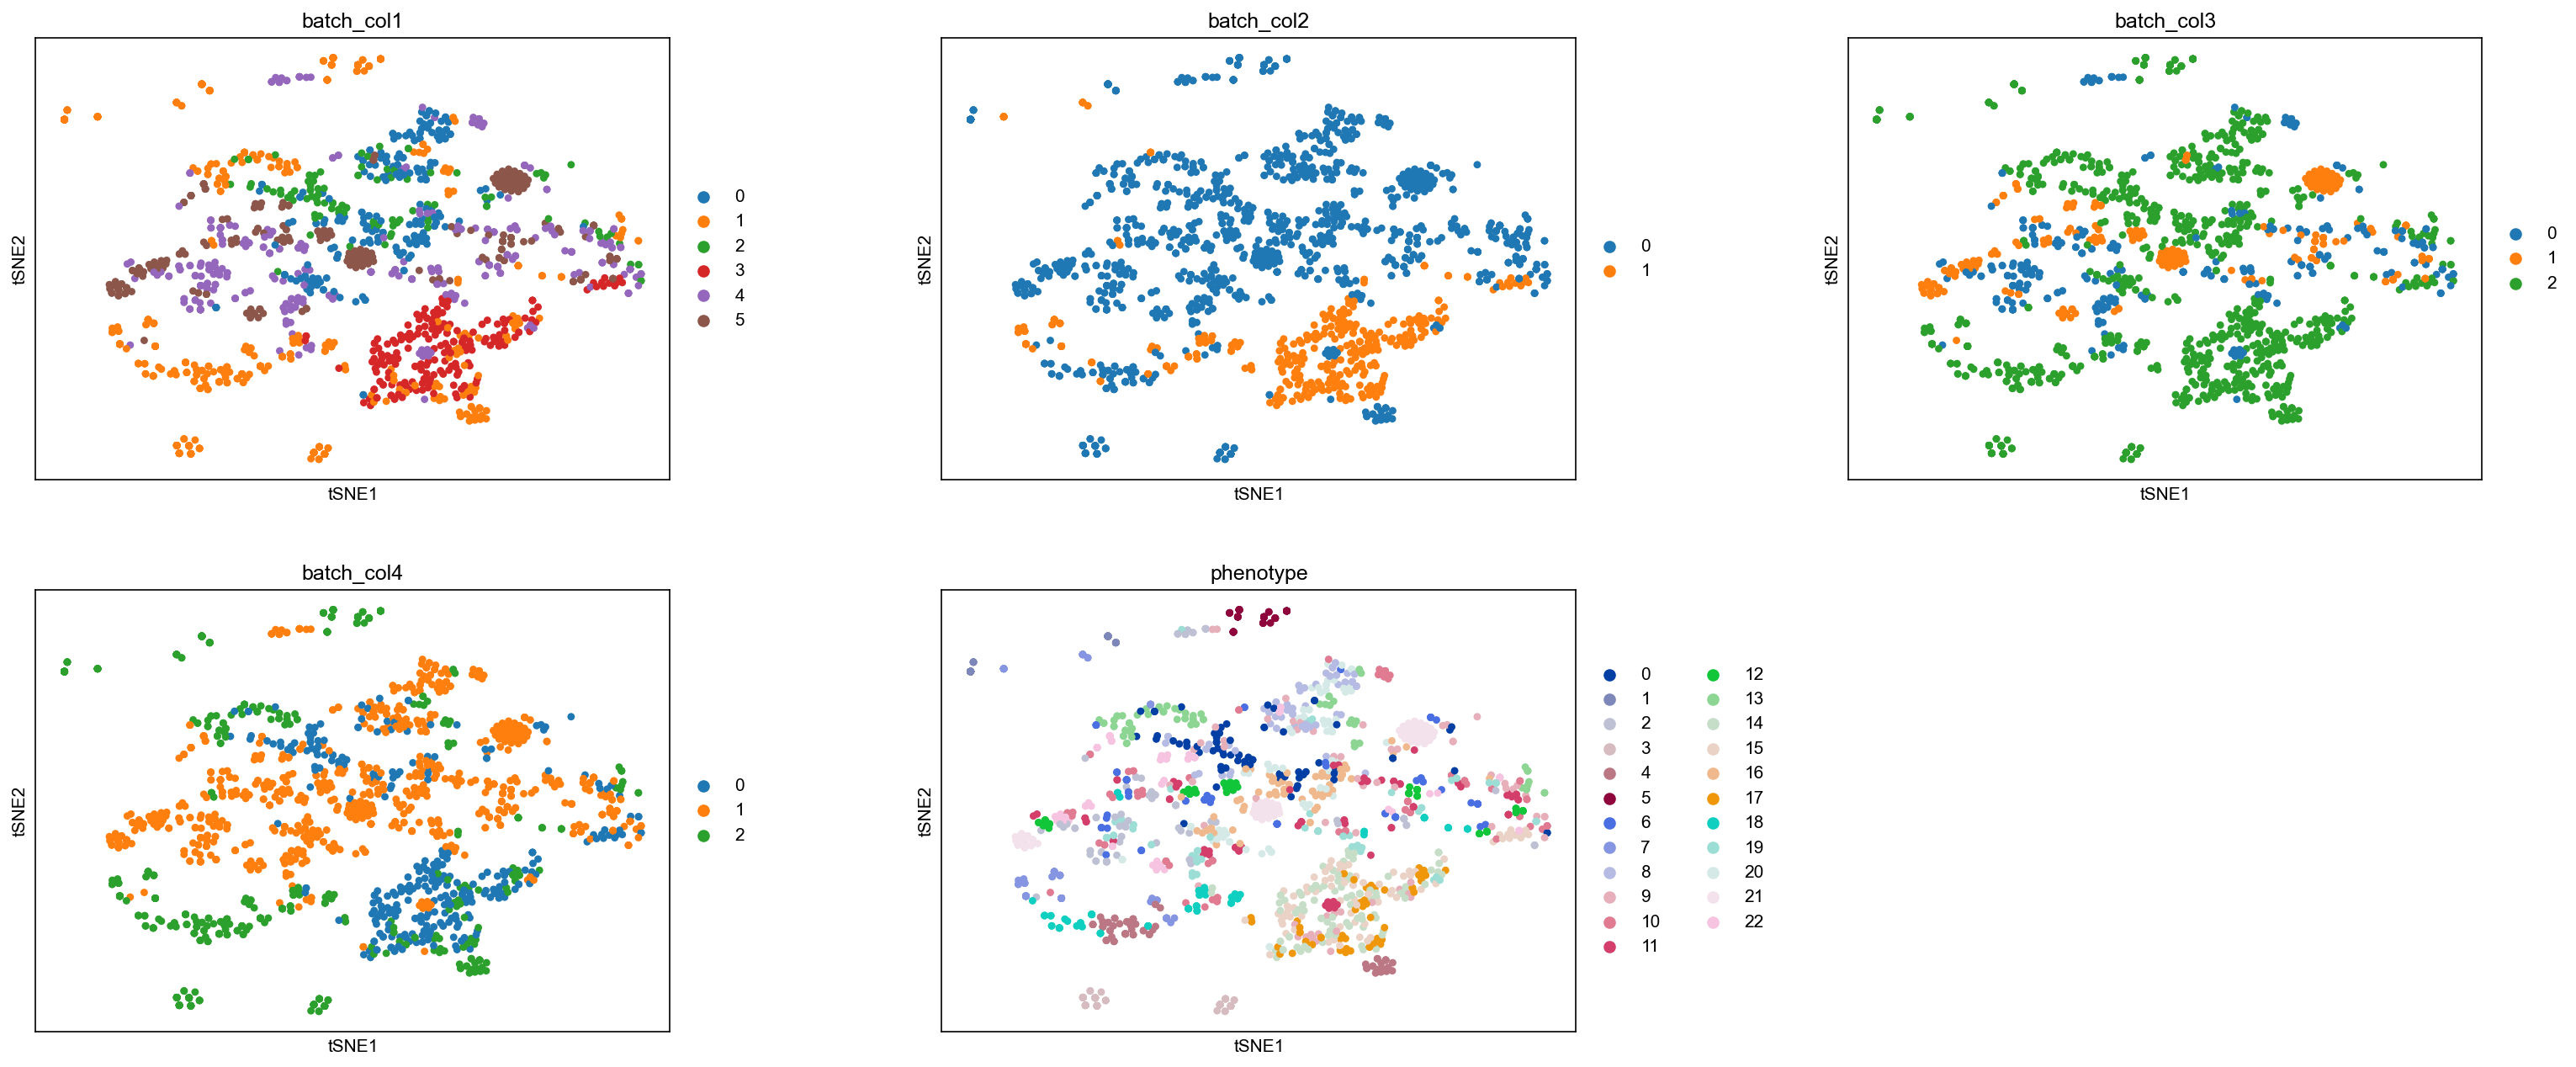

In [64]:
def verify_latent_space(model, dataloader, device):
    model.eval()
    zs, batch_ids, phenos = [], [], []
    with torch.no_grad():
        for batch in dataloader:
            x, b_idx, qc, p_idx, lib_log = [b.to(device) for b in batch]
            _, _, z_mu, _ = model(x, b_idx, qc, p_idx, lib_log)
            zs.append(z_mu.cpu())
            batch_ids.append(b_idx.cpu()) 
            phenos.append(p_idx.cpu())

    z_concat = torch.cat(zs).numpy()
    p_concat = torch.cat(phenos).numpy()
    b_concat = torch.cat(batch_ids).numpy()

    adata = sc.AnnData(z_concat)
    adata.obs['phenotype'] = p_concat.astype(str)
    adata.obs['batch_col1'] = b_concat[:, 0].astype(str) 
    adata.obs['batch_col2'] = b_concat[:, 1].astype(str) 
    adata.obs['batch_col3'] = b_concat[:, 2].astype(str) 
    adata.obs['batch_col4'] = b_concat[:, 3].astype(str) 

    sc.pp.neighbors(adata)
    sc.tl.tsne(adata)
    sc.pl.tsne(adata, color=['batch_col1', 'batch_col2', 'batch_col3', 'batch_col4','phenotype'], wspace=0.3, ncols=3)
    return adata

adata_latent = verify_latent_space(model, train_loader, args.device)


[Check 1] Posterior Predictive Check (HC Index: 9)


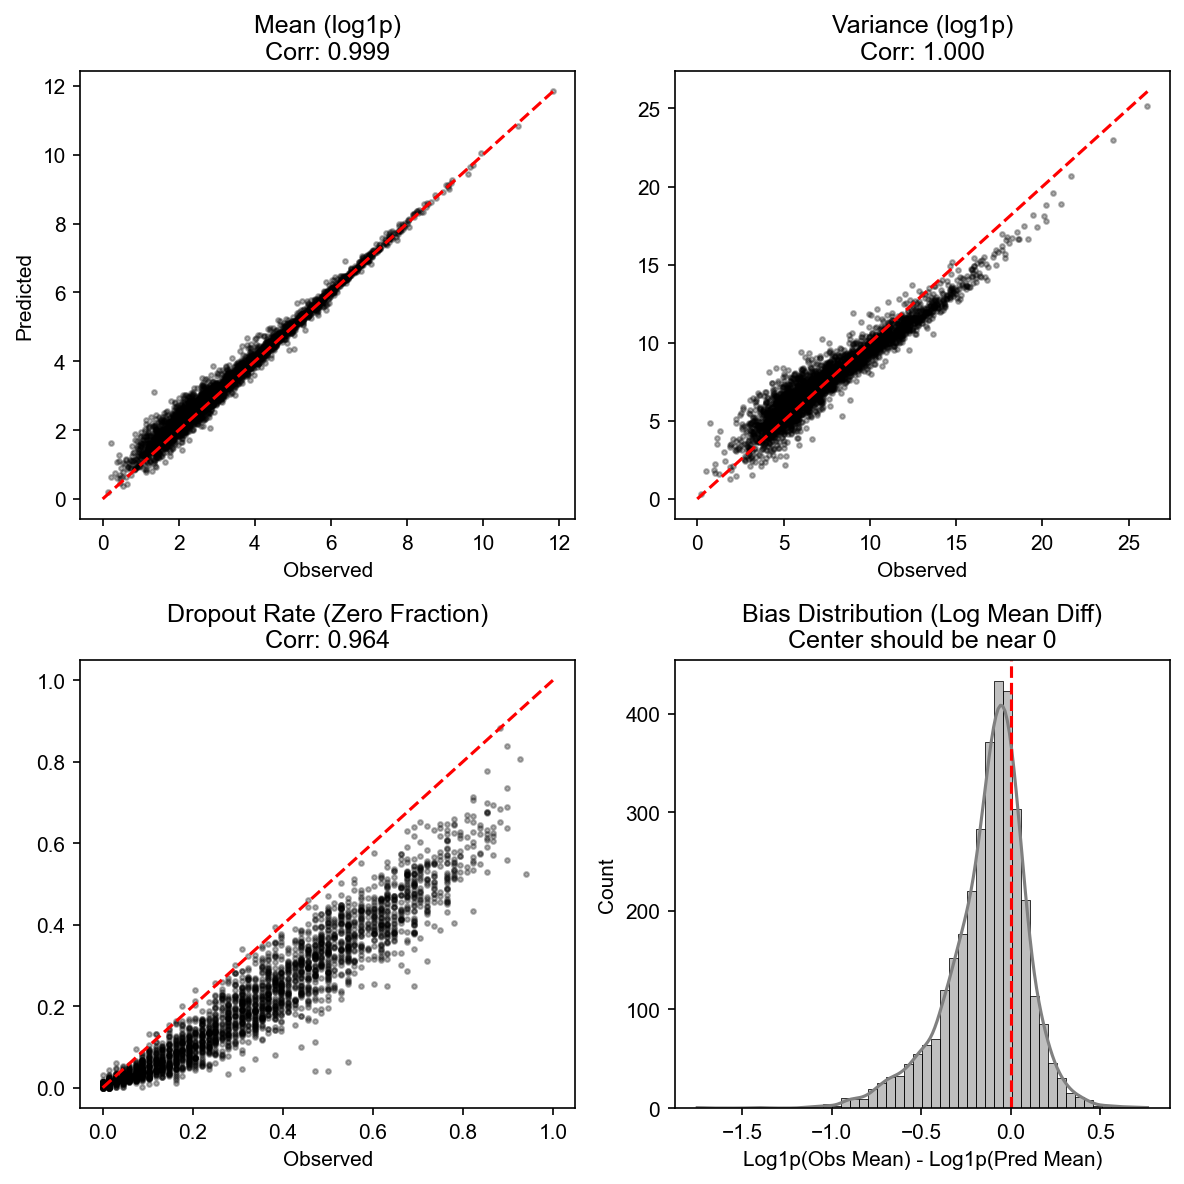


[Check 2] Residual vs QC Independence Evaluation


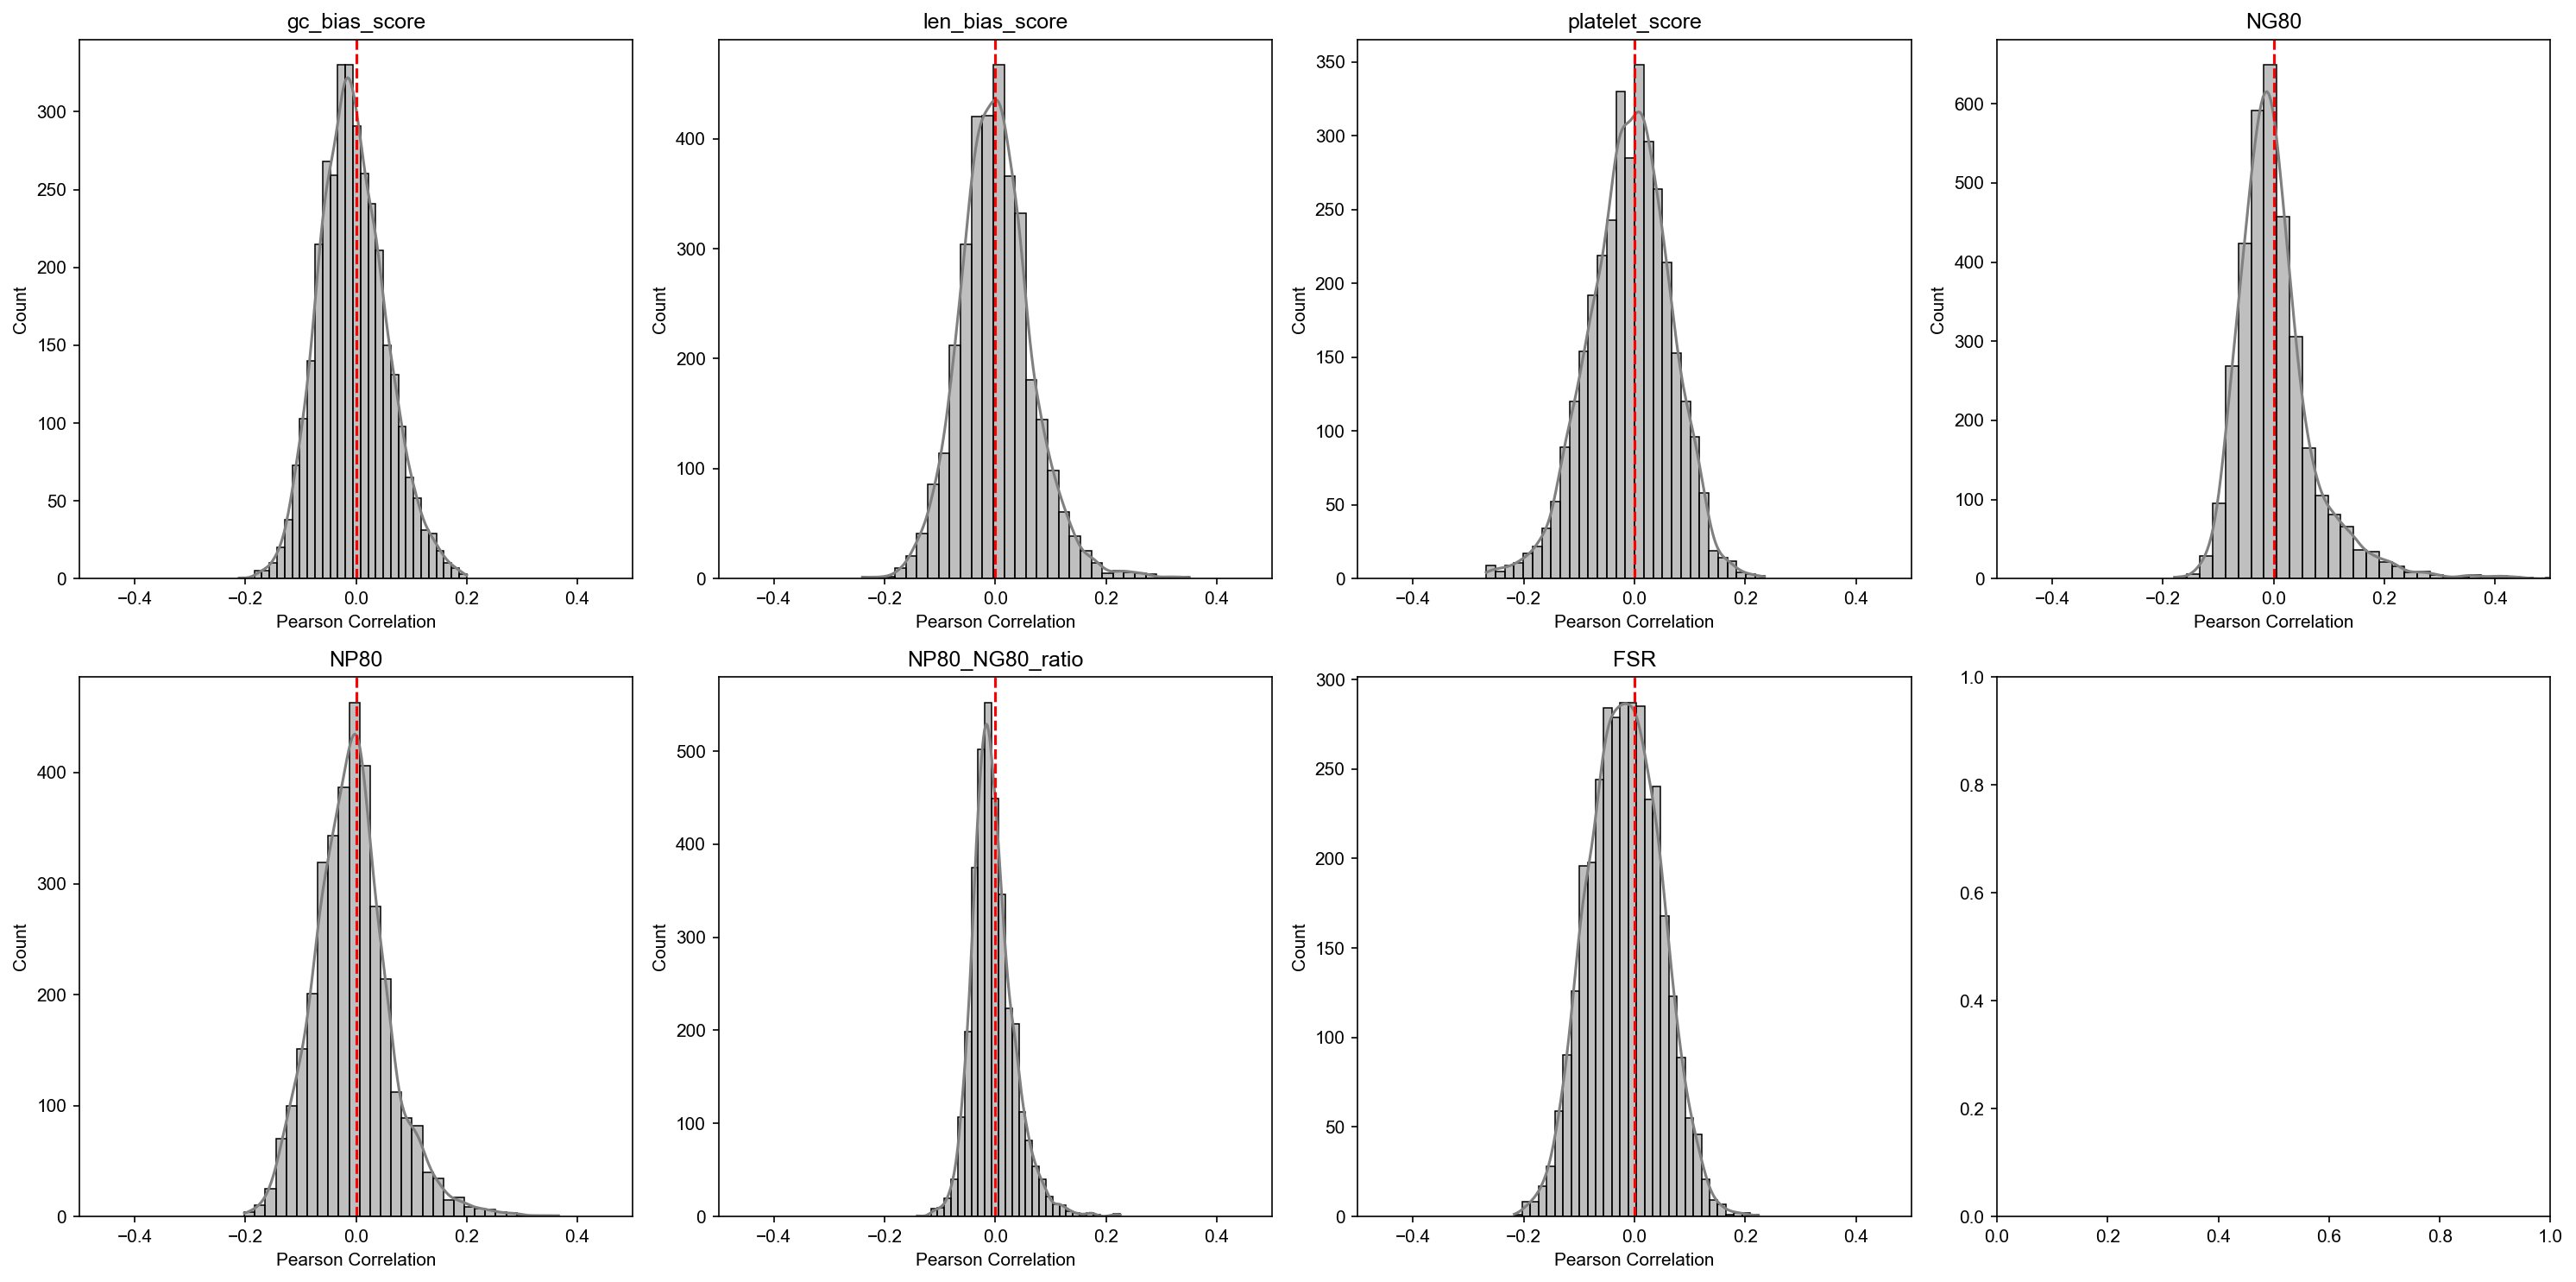

Mean Abs Correlations per QC: [np.float32(0.0057), np.float32(0.0019), np.float32(0.009), np.float32(0.0035), np.float32(0.0069), np.float32(0.0039), np.float32(0.0177)]

[Check 3] Visualizing HC Residual Structure with t-SNE & Silhouette Analysis


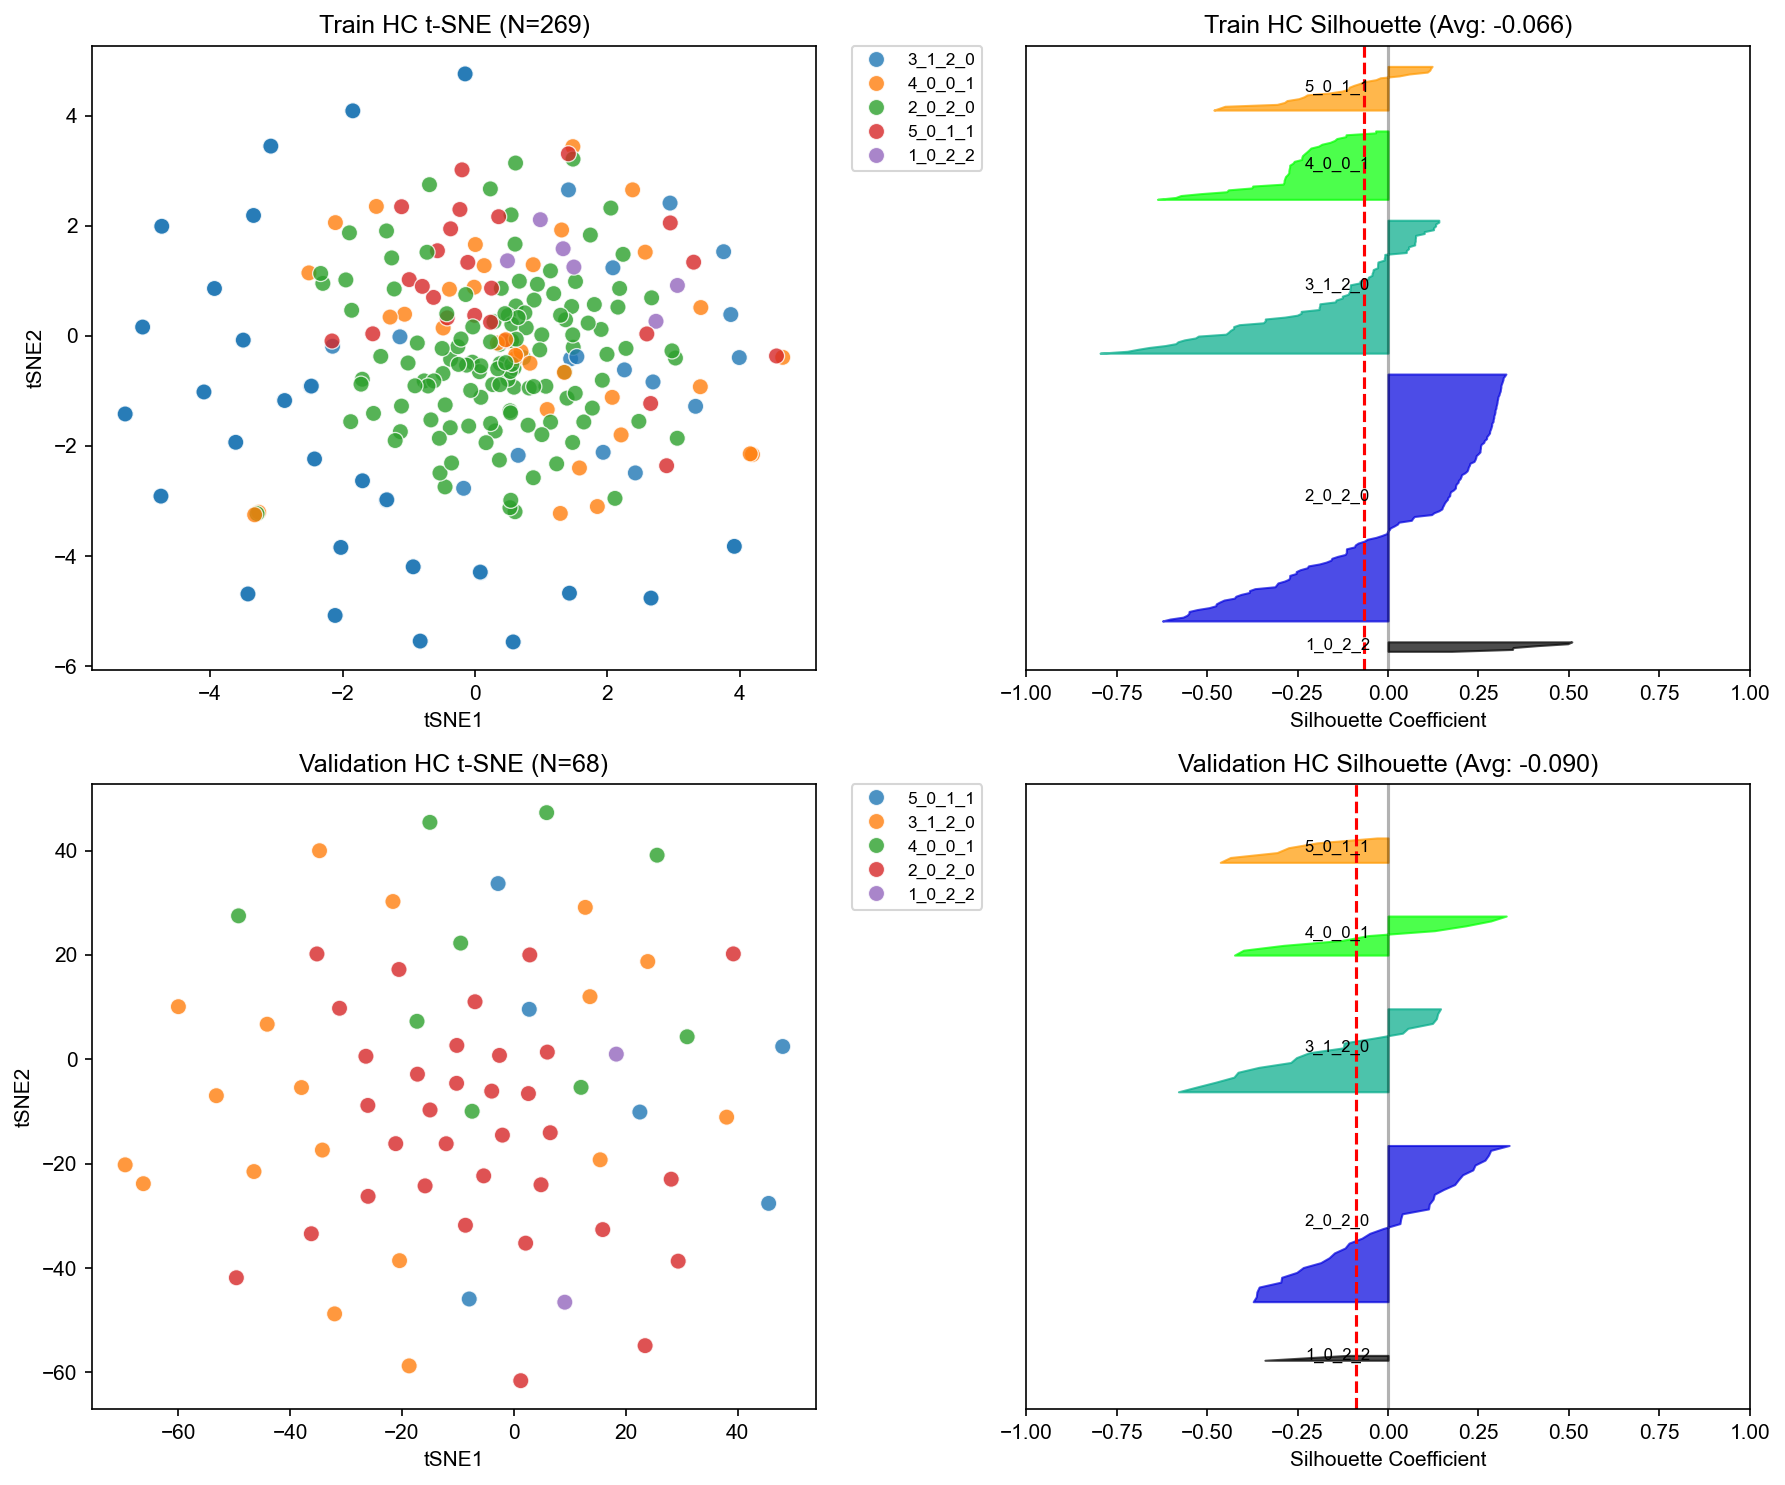

   [Train] Silhouette Score: -0.0663
   [Val]   Silhouette Score: -0.0897

[Check 4] Counterfactual Anomaly Detection Evaluation
   -> Evaluating deviation from the Normative HC Manifold without external classifiers.
   -> [Fidelity] HC Baseline Anomaly Score: Mean=87.52, Std=62.34


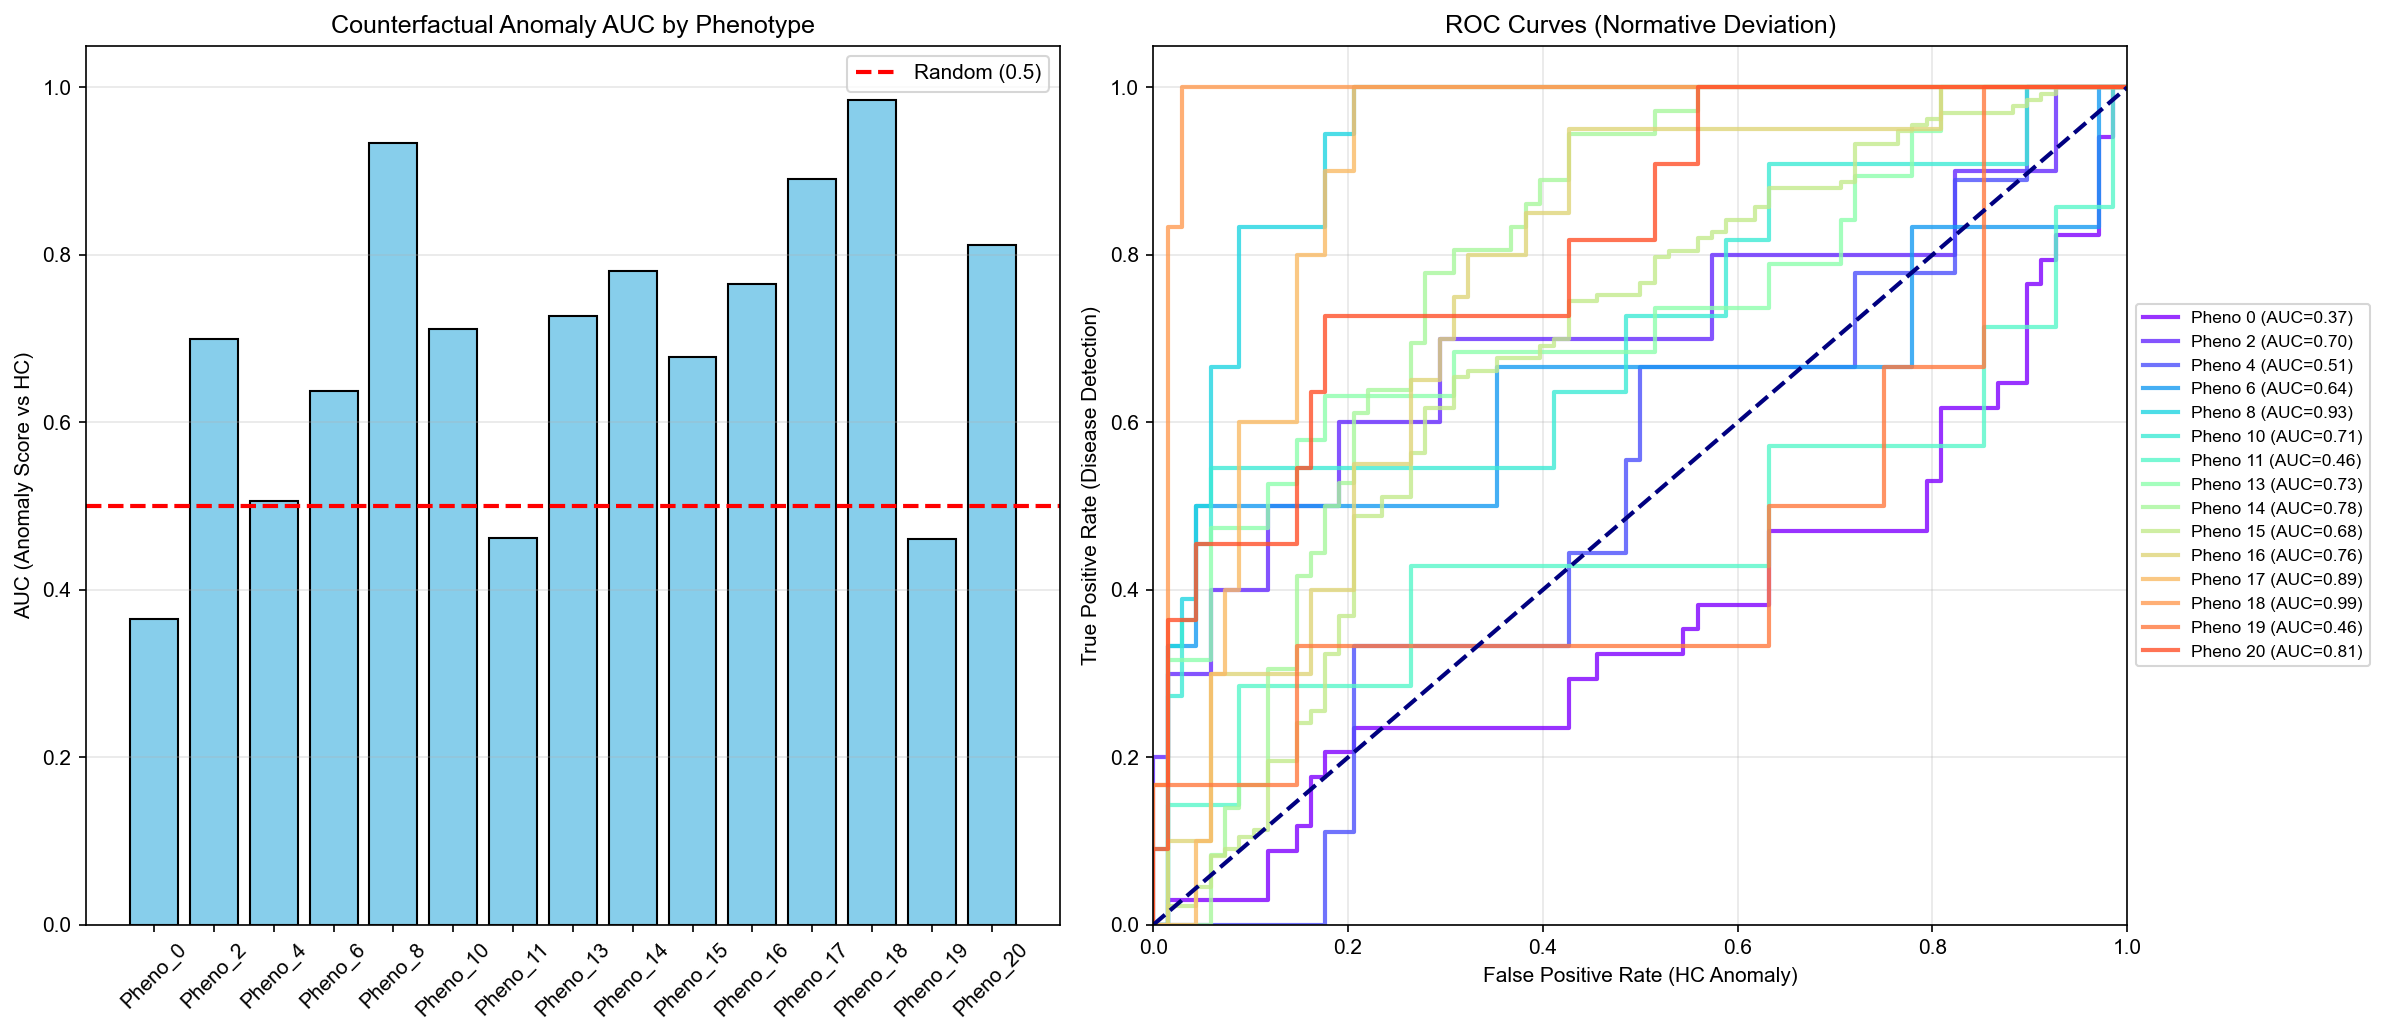

   [Result] Mean Disease AUC (Counterfactual): 0.694
   ✅ Strong Biological Deviation in: [np.int64(2), np.int64(8), np.int64(10), np.int64(13), np.int64(14), np.int64(16), np.int64(17), np.int64(18), np.int64(20)]

[Check 5] Phenotype Offset Embedding Analysis


/tmp/ipykernel_41397/3143465060.py:388: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df_plot, x='Phenotype', y='Value', scale='width')


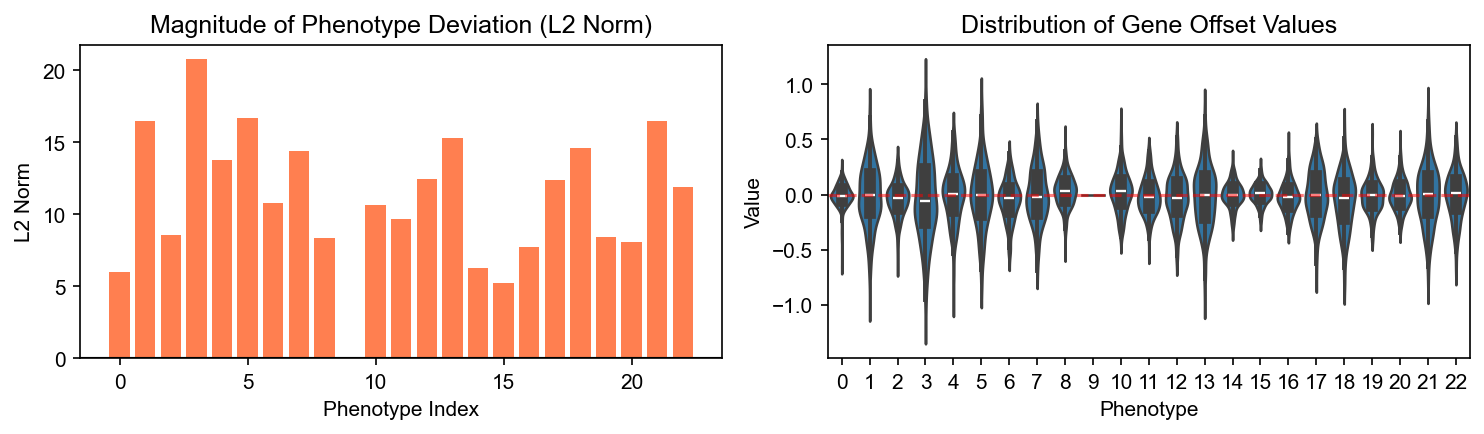

In [65]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples, roc_curve, auc
import matplotlib.cm as cm
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.decomposition import PCA

def get_normative_data(model, loader, device, hc_index):
    model.eval()
    obs_list, mu_list, theta_list = [], [], [] # theta_list 추가
    qc_list, pheno_list, batch_parts_list = [], [], []
    
    with torch.no_grad():
        for batch in loader:
            x, b_idx, qc, p_idx, lib_log = [b.to(device) for b in batch]
            hc_input = torch.full_like(p_idx, hc_index)
            mu, theta, _, _ = model(x, b_idx, qc, hc_input, lib_log) 
            
            obs_list.append(x.cpu().numpy())
            mu_list.append(mu.cpu().numpy())
            theta_list.append(theta.cpu().numpy()) # 저장
            qc_list.append(qc.cpu().numpy())
            pheno_list.append(p_idx.cpu().numpy())
            batch_parts_list.append(b_idx.cpu().numpy())

    X = np.concatenate(obs_list, axis=0)       
    Mu = np.concatenate(mu_list, axis=0)       
    Theta = np.concatenate(theta_list, axis=0) # [수정] 크기가 (N, Genes)가 됩니다.
    QC = np.concatenate(qc_list, axis=0)       
    Pheno = np.concatenate(pheno_list, axis=0) 
    Batch_Indices = np.concatenate(batch_parts_list, axis=0) 
    
    Variance = Mu + (Mu**2 / (Theta + 1e-8))
    Residual = (X - Mu) / np.sqrt(Variance + 1e-8)
    
    batch_str = []
    for i in range(Batch_Indices.shape[0]):
        row_str = "_".join(Batch_Indices[i].astype(str))
        batch_str.append(row_str)
    Batch_Granular = np.array(batch_str)

    return {
        'X': X, 'Mu': Mu, 'Theta': Theta, 
        'Residual': Residual, 
        'QC': QC, 'Pheno': Pheno, 
        'Batch_Granular': Batch_Granular,
        'Batch_Indices': Batch_Indices
    }



def check_1_ppc(data, hc_index):
    print(f"\n[Check 1] Posterior Predictive Check (HC Index: {hc_index})")
    hc_mask = (data['Pheno'] == hc_index)
    if hc_mask.sum() == 0:
        print("⚠️ Warning: No HC samples found.")
        return

    # [수정 1] X, Mu와 동일하게 Theta도 HC 샘플만 추출
    X_hc = data['X'][hc_mask]
    Mu_hc = data['Mu'][hc_mask]
    Theta_hc = data['Theta'][hc_mask] 
    
    obs_mean = np.mean(X_hc, axis=0)
    pred_mean = np.mean(Mu_hc, axis=0)
    obs_var = np.var(X_hc, axis=0)
    
    # [수정 2] data['Theta'] 대신 잘라낸 Theta_hc 사용
    pred_var_matrix = Mu_hc + (Mu_hc**2 / (Theta_hc + 1e-8))
    pred_var = np.mean(pred_var_matrix, axis=0)
    
    obs_dropout = np.mean(X_hc == 0, axis=0)
    
    # [수정 3] 이제 Theta_hc가 2차원 매트릭스이므로 flatten() 없이 바로 연산 가능
    pred_dropout_prob = (Theta_hc / (Theta_hc + Mu_hc + 1e-8)) ** Theta_hc
    pred_dropout = np.mean(pred_dropout_prob, axis=0)
    
    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    axes = axes.flatten()
    
    # 1. Mean
    axes[0].scatter(np.log1p(obs_mean), np.log1p(pred_mean), alpha=0.3, s=5, c='black')
    axes[0].plot([0, np.log1p(obs_mean).max()], [0, np.log1p(obs_mean).max()], 'r--')
    axes[0].set_title(f"Mean (log1p)\nCorr: {np.corrcoef(obs_mean, pred_mean)[0,1]:.3f}")
    axes[0].set_xlabel("Observed")
    axes[0].set_ylabel("Predicted")

    # 2. Variance
    axes[1].scatter(np.log1p(obs_var), np.log1p(pred_var), alpha=0.3, s=5, c='black')
    axes[1].plot([0, np.log1p(obs_var).max()], [0, np.log1p(obs_var).max()], 'r--')
    axes[1].set_title(f"Variance (log1p)\nCorr: {np.corrcoef(obs_var, pred_var)[0,1]:.3f}")
    axes[1].set_xlabel("Observed")
    
    # 3. Dropout
    axes[2].scatter(obs_dropout, pred_dropout, alpha=0.3, s=5, c='black')
    axes[2].plot([0, 1], [0, 1], 'r--')
    axes[2].set_title(f"Dropout Rate (Zero Fraction)\nCorr: {np.corrcoef(obs_dropout, pred_dropout)[0,1]:.3f}")
    axes[2].set_xlabel("Observed")
    
    # 4. Bias Distribution (Obs - Pred)
    diff = np.log1p(obs_mean) - np.log1p(pred_mean)
    sns.histplot(diff, ax=axes[3], kde=True, bins=50, color='gray')
    axes[3].axvline(0, color='r', linestyle='--')
    axes[3].set_title("Bias Distribution (Log Mean Diff)\nCenter should be near 0")
    axes[3].set_xlabel("Log1p(Obs Mean) - Log1p(Pred Mean)")
    
    plt.tight_layout()
    plt.show()


def check_2_residual_qc_independence(data, qc_columns=None):
    print("\n[Check 2] Residual vs QC Independence Evaluation")
    residuals = data['Residual']
    qc_matrix = data['QC']
    n_qc = qc_matrix.shape[1]
    
    if qc_columns is None:
        qc_columns = [f"QC_{i}" for i in range(n_qc)]
        
    fig, axes = plt.subplots(2, (n_qc + 1) // 2, figsize=(20, 10))
    axes = axes.flatten()
    
    stats_list = []
    
    for i in range(n_qc):
        qc_vec = qc_matrix[:, i]
        corrs = []
        # QC Vector Normalize
        qc_centered = qc_vec - qc_vec.mean()
        qc_norm = qc_centered / (np.std(qc_centered) + 1e-8)
        # Residual Normalize (Gene-wise)
        res_mean = residuals.mean(axis=0)
        res_std = residuals.std(axis=0) + 1e-8
        res_norm = (residuals - res_mean) / res_std
        # Correlation = (X_norm * Y_norm) / N
        corrs = np.dot(res_norm.T, qc_norm) / residuals.shape[0]
        sns.histplot(corrs, ax=axes[i], bins=30, kde=True, color='gray')
        axes[i].axvline(0, color='r', linestyle='--')
        axes[i].set_title(f"{qc_columns[i]}")
        axes[i].set_xlabel("Pearson Correlation")
        axes[i].set_xlim(-0.5, 0.5) # 상관계수가 0.5 넘어가면 문제 있음
        
        mean_corr = np.mean(corrs)
        stats_list.append(mean_corr)

    plt.tight_layout()
    plt.show()
    print(f"Mean Abs Correlations per QC: {[round(abs(x), 4) for x in stats_list]}")
    
    
    
def check_3_hc_residual_tsne_silhouette(train_data, val_data, hc_index):
    print("\n[Check 3] Visualizing HC Residual Structure with t-SNE & Silhouette Analysis")
    
    # 1. 서브루틴: 데이터 추출 및 분석 함수
    def analyze_subset(data, subset_name):
        hc_mask = (data['Pheno'] == hc_index)
        if hc_mask.sum() == 0:
            return None
            
        X_res = data['Residual'][hc_mask]
        y_batch = data['Batch_Granular'][hc_mask]
        n_samples = len(X_res)
        
        # t-SNE
        perplex = min(30, max(5, n_samples // 5))
        tsne = TSNE(n_components=2, perplexity=perplex, random_state=42, init='pca', learning_rate='auto')
        X_tsne = tsne.fit_transform(X_res)
        
        df_tsne = pd.DataFrame({'tSNE1': X_tsne[:, 0], 'tSNE2': X_tsne[:, 1], 'Batch': y_batch})
        
        # Silhouette Score
        unique_batches = np.unique(y_batch)
        n_batches = len(unique_batches)
        
        if n_batches > 1:
            avg_score = silhouette_score(X_tsne, y_batch)
            sample_scores = silhouette_samples(X_tsne, y_batch)
        else:
            avg_score = 0.0
            sample_scores = np.zeros(n_samples)
            
        return {
            'df': df_tsne, 'avg_score': avg_score, 
            'sample_scores': sample_scores, 'unique_batches': unique_batches,
            'n_batches': n_batches, 'n_samples': n_samples
        }
    train_res = analyze_subset(train_data, "Train")
    val_res = analyze_subset(val_data, "Val")
    
    if train_res is None and val_res is None:
        print("⚠️ No HC samples found in both Train and Val sets.")
        return
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    def plot_results(res_dict, row_idx, title_prefix):
        if res_dict is None:
            axes[row_idx, 0].text(0.5, 0.5, "No HC Samples", ha='center', va='center')
            axes[row_idx, 1].text(0.5, 0.5, "No HC Samples", ha='center', va='center')
            return
            
        df = res_dict['df']
        avg_score = res_dict['avg_score']
        sample_scores = res_dict['sample_scores']
        unique_batches = res_dict['unique_batches']
        
        # --- t-SNE Plot ---
        # 범례가 너무 길어지는 것을 방지하기 위해 상위 10개만 표시
        top_batches = df['Batch'].value_counts().head(10).index
        df['Batch_Label'] = df['Batch'].apply(lambda x: x if x in top_batches else 'Other')
        
        sns.scatterplot(data=df, x='tSNE1', y='tSNE2', hue='Batch_Label', 
                        ax=axes[row_idx, 0], palette='tab10', s=60, alpha=0.8)
        axes[row_idx, 0].set_title(f"{title_prefix} t-SNE (N={res_dict['n_samples']})")
        axes[row_idx, 0].legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize='small')
        
        # --- Silhouette Plot ---
        axes[row_idx, 1].set_xlim([-1, 1])
        axes[row_idx, 1].set_ylim([0, res_dict['n_samples'] + (res_dict['n_batches'] + 1) * 10])
        axes[row_idx, 1].set_title(f"{title_prefix} Silhouette (Avg: {avg_score:.3f})")
        axes[row_idx, 1].set_xlabel("Silhouette Coefficient")
        axes[row_idx, 1].set_yticks([]) # Y축 눈금 제거
        
        if res_dict['n_batches'] <= 1:
            axes[row_idx, 1].text(0.5, 0.5, "Only 1 Batch (Score N/A)", ha='center', va='center')
            return

        y_lower = 10
        batches_to_plot = unique_batches if res_dict['n_batches'] <= 15 else top_batches
        
        for i, batch_label in enumerate(batches_to_plot):
            ith_scores = sample_scores[df['Batch'] == batch_label]
            ith_scores.sort()
            
            size_cluster_i = ith_scores.shape[0]
            y_upper = y_lower + size_cluster_i
            
            color = cm.nipy_spectral(float(i) / len(batches_to_plot))
            axes[row_idx, 1].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_scores,
                                           facecolor=color, edgecolor=color, alpha=0.7)
            
            if res_dict['n_batches'] <= 15:
                axes[row_idx, 1].text(-0.05, y_lower + 0.5 * size_cluster_i, str(batch_label), 
                                      ha='right', va='center', fontsize=8)
            y_lower = y_upper + 10
            
        axes[row_idx, 1].axvline(x=avg_score, color="red", linestyle="--")
        axes[row_idx, 1].axvline(x=0, color="black", linestyle="-", alpha=0.3)
        if res_dict['n_batches'] > 15:
            axes[row_idx, 1].text(0.5, 0.95, "(Showing top batches only)", transform=axes[row_idx, 1].transAxes, ha='center', color='gray')

    # 플롯 그리기
    plot_results(train_res, 0, "Train HC")
    plot_results(val_res, 1, "Validation HC")
    
    plt.tight_layout()
    plt.show()
    
    if train_res: print(f"   [Train] Silhouette Score: {train_res['avg_score']: .4f}")
    if val_res:   print(f"   [Val]   Silhouette Score: {val_res['avg_score']: .4f}")

def check_4_counterfactual_anomaly_detection(data, hc_index):
    """
    [Check 4] 외부 분류기 없이 모델의 순수 '정상 매니폴드 일반화' 능력을 평가합니다.
    - 데이터의 잔차(Residual)는 "해당 조건에서의 HC 기댓값"과 "실제 관측값"의 차이입니다.
    - 잔차 벡터의 크기(L2 Norm)를 생물학적 이탈도를 나타내는 Anomaly Score로 사용합니다.
    """
    print("\n[Check 4] Counterfactual Anomaly Detection Evaluation")
    print("   -> Evaluating deviation from the Normative HC Manifold without external classifiers.")
    
    y_pheno = data['Pheno']
    X_res = data['Residual'] 
    
    # 1. Anomaly Score 정의: Counterfactual 잔차의 L2 Norm (유클리디안 거리)
    # 정상이면 모델의 예상과 일치하여 0에 가깝고, 질병이면 생물학적 신호만큼 모델의 예상에서 빗나가 거리가 커집니다.
    anomaly_scores = np.linalg.norm(X_res, axis=1)
    
    # 2. HC Fidelity (정상 데이터의 기준점 확인)
    hc_mask = (y_pheno == hc_index)
    if np.sum(hc_mask) > 0:
        hc_scores = anomaly_scores[hc_mask]
        print(f"   -> [Fidelity] HC Baseline Anomaly Score: Mean={np.mean(hc_scores):.2f}, Std={np.std(hc_scores):.2f}")
    else:
        print("⚠️ Warning: No HC samples found for baseline comparison.")
        return

    classes = np.unique(y_pheno)
    classes = classes[classes != hc_index] 
    results = {}
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    colors = cm.rainbow(np.linspace(0, 1, len(classes)))
    
    for idx, cls in enumerate(classes):
        cls_mask = (y_pheno == cls)
        # 평가를 위한 최소 샘플 수 조건
        if np.sum(cls_mask) < 5: 
            continue 
            
        # 비교를 위해 HC와 특정 질환 샘플만 병합
        combined_mask = cls_mask | hc_mask
        y_true = (y_pheno[combined_mask] == cls).astype(int) # 질환이 Positive(1), HC가 Negative(0)
        y_scores = anomaly_scores[combined_mask]
        
        try:
            fpr, tpr, _ = roc_curve(y_true, y_scores)
            roc_auc = auc(fpr, tpr)
            results[cls] = roc_auc
            
            label_text = f"Pheno {cls} (AUC={roc_auc:.2f})"
            axes[1].plot(fpr, tpr, color=colors[idx], lw=2, alpha=0.8, label=label_text)
        except Exception as e:
            continue

    if not results:
        print("⚠️ Not enough samples for valid AUC calculations.")
        return

    # --- [Left Plot] Bar Chart ---
    names = [f"Pheno_{k}" for k in results.keys()]
    values = list(results.values())
    
    axes[0].bar(names, values, color='skyblue', edgecolor='black')
    axes[0].axhline(0.5, color='r', linestyle='--', linewidth=2, label='Random (0.5)')
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel("AUC (Anomaly Score vs HC)")
    axes[0].set_title("Counterfactual Anomaly AUC by Phenotype")
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].legend()

    # --- [Right Plot] ROC Curve ---
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate (HC Anomaly)')
    axes[1].set_ylabel('True Positive Rate (Disease Detection)')
    axes[1].set_title('ROC Curves (Normative Deviation)')
    
    if len(results) > 10:
        axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')
    else:
        axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    print(f"   [Result] Mean Disease AUC (Counterfactual): {np.mean(values):.3f}")
    high_signal = [k for k, v in results.items() if v > 0.7]
    print(f"   ✅ Strong Biological Deviation in: {high_signal}")

def check_5_pheno_offset_distribution(model, pheno_le=None):
    print("\n[Check 5] Phenotype Offset Embedding Analysis")
    
    # Embedding Weight 가져오기
    # shape: (n_phenotypes, n_genes)
    offsets = model.pheno_offset.weight.detach().cpu().numpy()
    n_phenos = offsets.shape[0]
    
    # 1. L2 Norm per Phenotype (얼마나 HC에서 멀어졌는가?)
    norms = np.linalg.norm(offsets, axis=1)
    
    plt.figure(figsize=(10, 3))
    
    plt.subplot(1, 2, 1)
    plt.bar(range(n_phenos), norms, color='coral')
    plt.title("Magnitude of Phenotype Deviation (L2 Norm)")
    plt.xlabel("Phenotype Index")
    plt.ylabel("L2 Norm")
    plt.axhline(0, color='black')
    plt.subplot(1, 2, 2)
    # 데이터프레임 변환 for seaborn
    plot_data = []
    for i in range(n_phenos):
        vals = offsets[i, :]
        # 너무 많으면 샘플링 (optional)
        for v in vals[::10]: # 1/10 sampling for speed
            plot_data.append({'Phenotype': i, 'Value': v})
            
    df_plot = pd.DataFrame(plot_data)
    sns.violinplot(data=df_plot, x='Phenotype', y='Value', scale='width')
    plt.title("Distribution of Gene Offset Values")
    plt.axhline(0, color='r', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()



clean_train_loader = DataLoader(
    train_loader.dataset, 
    batch_size=train_loader.batch_size, 
    shuffle=False
)
train_data_clean = get_normative_data(model, clean_train_loader, args.device, args.hc_index)
val_data = get_normative_data(model, val_loader, args.device, args.hc_index)

check_1_ppc(val_data, args.hc_index)
check_2_residual_qc_independence(val_data, qc_columns=bias_metrics)
check_3_hc_residual_tsne_silhouette(train_data_clean, val_data, args.hc_index)
check_4_counterfactual_anomaly_detection(val_data, args.hc_index)
check_5_pheno_offset_distribution(model)

In [66]:
trainer.save_checkpoint("./TestModels/NormativeModel/GlobalDisp_v2.pt")

💾 Checkpoint saved at Epoch 249 to ./TestModels/NormativeModel/GlobalDisp_v2.pt


### Zero-Shot LOPO Validation


🚀 Starting Zero-Shot LOPO Anomaly Detection

[LOPO Target] Evaluating Zero-shot performance on: NASH
✅ Global Intercept Initialized (Scale Fixed).
🚀 Start Training on cuda | Epochs: 250
[Ep 000] Train Loss: 30106.48  | Beta: 0.00 | Warmup: True
[Ep 005] Train Loss: 21834.96  | Beta: 0.50 | Warmup: True
[Ep 010] Train Loss: 19091.40  | Beta: 1.00 | Warmup: True
[Ep 015] Train Loss: 17768.89  | Beta: 1.50 | Warmup: True
[Ep 020] Train Loss: 16978.99  | Beta: 2.00 | Warmup: True
[Ep 025] Train Loss: 16592.18  | Beta: 2.00 | Warmup: True
[Ep 030] Train Loss: 16168.45  | Beta: 2.00 | Warmup: True
[Ep 035] Train Loss: 15872.90  | Beta: 2.00 | Warmup: True
[Ep 040] Train Loss: 15454.76  | Beta: 2.00 | Warmup: True
[Ep 045] Train Loss: 15287.23  | Beta: 2.00 | Warmup: True
[Ep 050] Train Loss: 14975.27  | Beta: 2.00 | Warmup: True
[Ep 055] Train Loss: 14647.18  | Beta: 2.00 | Warmup: True
[Ep 060] Train Loss: 14481.86  | Beta: 2.00 | Warmup: True
[Ep 065] Train Loss: 14231.64  | Beta: 2.00 | 

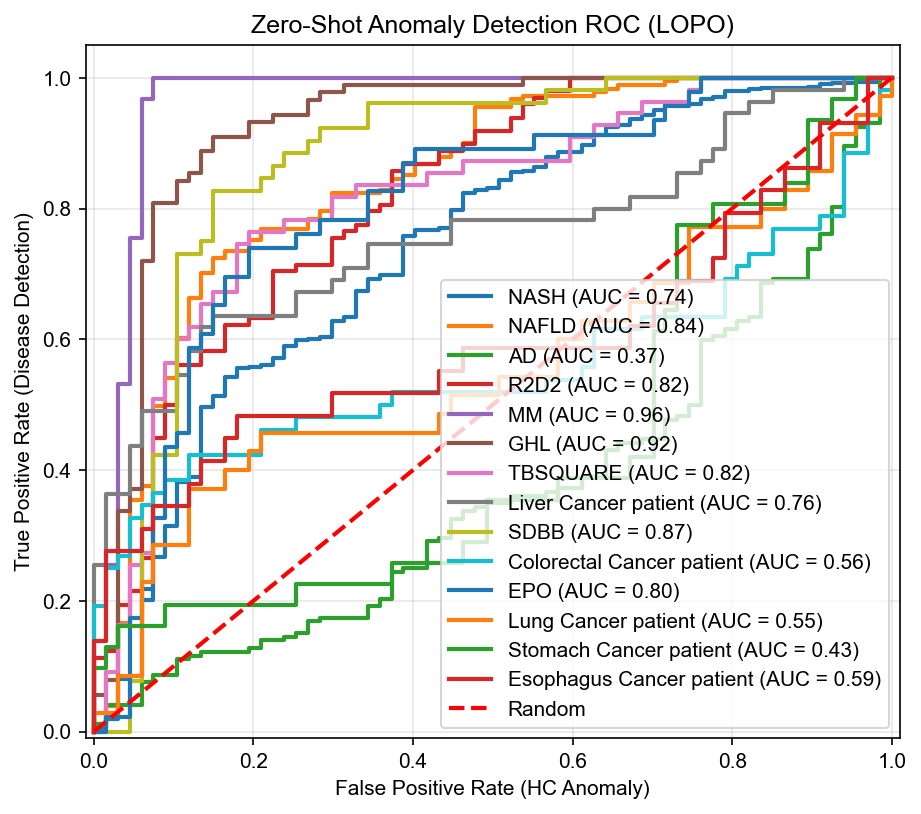

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import DataLoader
import torch

def run_zero_shot_lopo_evaluation(expr_np, batch_df, qc_df, label_df, args, target_phenos, hc_label="Healthy Control"):
    print("\n" + "="*50)
    print("🚀 Starting Zero-Shot LOPO Anomaly Detection")
    print("="*50)
    
    # 1. Global Batch Encoding
    global_batch_encoded = []
    n_batch_subcats = []
    for col in batch_df.columns:
        le = LabelEncoder()
        encoded = le.fit_transform(batch_df[col].astype(str))
        global_batch_encoded.append(encoded)
        n_batch_subcats.append(len(le.classes_))
    
    args.n_batch_subcategories = n_batch_subcats
    batch_indices_global = np.stack(global_batch_encoded, axis=1)
    
    # 2. Phenotype Encoding (label_df가 DataFrame일 경우 1D Array로 평탄화)
    le_pheno = LabelEncoder()
    y_pheno_global = le_pheno.fit_transform(np.ravel(label_df))
    args.hc_index = le_pheno.transform([hc_label])[0]
    
    zero_shot_results = {}
    
    for target_name in target_phenos:
        print(f"\n[LOPO Target] Evaluating Zero-shot performance on: {target_name}")
        target_idx = le_pheno.transform([target_name])[0]
        
        # --- [수정된 Data Split 로직] ---
        # HC 인덱스를 찾아서 20%를 Test용으로 무작위 추출
        hc_indices = np.where(y_pheno_global == args.hc_index)[0]
        np.random.seed(42)
        hc_test_idx = np.random.choice(hc_indices, size=int(len(hc_indices) * 0.2), replace=False)
        
        # Train / Test 마스크 초기화
        train_mask = np.ones_like(y_pheno_global, dtype=bool)
        test_mask = np.zeros_like(y_pheno_global, dtype=bool)
        
        # Train 마스크 설정: Target 질환 제외, Test용 HC 제외
        train_mask[y_pheno_global == target_idx] = False
        train_mask[hc_test_idx] = False
        
        # Test 마스크 설정: Target 질환 전체 + Test용 HC 전체
        test_mask[y_pheno_global == target_idx] = True
        test_mask[hc_test_idx] = True
        # -------------------------------
        
        # Train Set 구성
        x_train_raw = expr_np[train_mask]
        b_train = batch_indices_global[train_mask]
        qc_train_raw = qc_df.iloc[train_mask].values if isinstance(qc_df, pd.DataFrame) else qc_df[train_mask]
        y_train = y_pheno_global[train_mask]
        
        # Test Set 구성
        x_test_raw = expr_np[test_mask]
        b_test = batch_indices_global[test_mask]
        qc_test_raw = qc_df.iloc[test_mask].values if isinstance(qc_df, pd.DataFrame) else qc_df[test_mask]
        y_test = y_pheno_global[test_mask]
        
        # 스케일링 (Train 기준으로 Test 적용)
        scaler = StandardScaler()
        qc_train = scaler.fit_transform(qc_train_raw)
        qc_test = scaler.transform(qc_test_raw)
        
        # Library Size 계산
        lib_train = np.log(x_train_raw.sum(axis=1) + 1)
        lib_test = np.log(x_test_raw.sum(axis=1) + 1)
        
        # 데이터셋 및 로더 생성
        train_ds = NormativeDataset(x_train_raw, b_train, qc_train, y_train, lib_train)
        test_ds = NormativeDataset(x_test_raw, b_test, qc_test, y_test, lib_test)
        
        train_loader = DataLoader(train_ds, batch_size=args.batch_size, shuffle=True)
        # Test Loader는 순서를 섞지 않고 샘플링
        test_loader = DataLoader(test_ds, batch_size=args.batch_size, shuffle=False)
        
        # --- Model Init & Training ---
        model = NormativeModel(args).to(args.device) 
        model.init_global_intercept(x_train_raw)
        
        trainer = NormativeTrainer(model, args, train_loader)
        trainer.train() 
        
        # --- Zero-shot Inference ---
        test_data_out = get_normative_data(model, test_loader, args.device, args.hc_index)
        
        # --- Anomaly Score 계산 (L2 Norm 거리) ---
        residuals = test_data_out['Residual']
        anomaly_scores = np.linalg.norm(residuals, axis=1) 
        
        # 라벨 설정 (Target=1, HC=0)
        true_labels = (test_data_out['Pheno'] == target_idx).astype(int)
        
        # AUC 계산
        fpr, tpr, _ = roc_curve(true_labels, anomaly_scores)
        roc_auc = auc(fpr, tpr)
        zero_shot_results[target_name] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc}
        
        print(f"   -> {target_name} Zero-shot AUC: {roc_auc:.3f}")
        
    # --- 종합 시각화 ---
    plt.figure(figsize=(7, 6))
    for name, res in zero_shot_results.items():
        plt.plot(res['fpr'], res['tpr'], lw=2, label=f"{name} (AUC = {res['auc']:.2f})")
        
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random')
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.05])
    plt.xlabel('False Positive Rate (HC Anomaly)')
    plt.ylabel('True Positive Rate (Disease Detection)')
    plt.title('Zero-Shot Anomaly Detection ROC (LOPO)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# 사용 예시
targets_to_test = ['NASH', 'NAFLD', 'AD', 'R2D2', 'MM',
                  'GHL', 'TBSQUARE', 'Liver Cancer patient', 'SDBB',
                  'Colorectal Cancer patient', 'EPO', 'Lung Cancer patient',
                  'Stomach Cancer patient',
                  'Esophagus Cancer patient']
run_zero_shot_lopo_evaluation(x_data, batch_df, qc_df, label_df, args, targets_to_test)